In [1]:
import torch
import os
import glob
import random
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.metrics import roc_curve, average_precision_score
from torchvision.transforms import Compose, Resize, ToTensor

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

DATA_DIR = "/content/work"
PROJECT_DIR = "/content/project"
OUTPUT_DIR = "/content/outputs_step7"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

True
Tesla T4
DATA_DIR: /content/work
PROJECT_DIR: /content/project
OUTPUT_DIR: /content/outputs_step7


In [2]:
!git clone https://github.com/AlessandroMarinai/MaskArchitectureAnomaly_CourseProject.git /content/project

Cloning into '/content/project'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 131 (delta 22), reused 13 (delta 13), pack-reused 56 (from 2)
Receiving objects: 100% (131/131), 26.87 MiB | 23.50 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [3]:
!pip install -q gdown

#!gdown --fuzzy "https://drive.google.com/file/d/1X57RfPr5FCemAIYAeNeev3AWPaW5Pjb1/view?usp=sharing" -O /content/work/eomt_cityscapes.bin
#!gdown --fuzzy "https://drive.google.com/file/d/1fF-bevMQjDjCb15xDoYQGPpVqJZNY0XO/view?usp=sharing" -O /content/work/eomt_coco.bin
!gdown --fuzzy "https://drive.google.com/file/d/1iDzHQ3HujgIv2fbcckGwLOYXbpKhQWz3/view?usp=sharing" -O /content/work/Anomaly_Validation_Datasets.zip


Downloading...
From (original): https://drive.google.com/uc?id=1iDzHQ3HujgIv2fbcckGwLOYXbpKhQWz3
From (redirected): https://drive.google.com/uc?id=1iDzHQ3HujgIv2fbcckGwLOYXbpKhQWz3&confirm=t&uuid=bcacb8b0-8e15-415d-9c22-b6d6abaf1eb7
To: /content/work/Anomaly_Validation_Datasets.zip
100% 329M/329M [00:04<00:00, 81.6MB/s]


In [4]:
!rm -rf /content/work/Validation_Dataset
!unzip -q /content/work/Anomaly_Validation_Datasets.zip -d /content/work/

!find /content/work -maxdepth 2 -type d | grep -v "__MACOSX" | sort

/content/work
/content/work/Validation_Dataset
/content/work/Validation_Dataset/FS_LostFound_full
/content/work/Validation_Dataset/fs_static
/content/work/Validation_Dataset/RoadAnomaly
/content/work/Validation_Dataset/RoadAnomaly21
/content/work/Validation_Dataset/RoadObsticle21


# Dataset paths

In [5]:
# to store all anomaly dataset roots in one dictionary
ANOMALY_DATASETS = {
    "SMIYC_RA21": "/content/work/Validation_Dataset/RoadAnomaly21",
    "SMIYC_RO21": "/content/work/Validation_Dataset/RoadObsticle21",
    "FS_LF": "/content/work/Validation_Dataset/FS_LostFound_full",
    "FS_Static": "/content/work/Validation_Dataset/fs_static",
    "RoadAnomaly": "/content/work/Validation_Dataset/RoadAnomaly",
}

for name, path in ANOMALY_DATASETS.items():
    print(f"{name}: {path} | exists = {os.path.exists(path)}")

SMIYC_RA21: /content/work/Validation_Dataset/RoadAnomaly21 | exists = True
SMIYC_RO21: /content/work/Validation_Dataset/RoadObsticle21 | exists = True
FS_LF: /content/work/Validation_Dataset/FS_LostFound_full | exists = True
FS_Static: /content/work/Validation_Dataset/fs_static | exists = True
RoadAnomaly: /content/work/Validation_Dataset/RoadAnomaly | exists = True


# evalAnomaly

In [6]:
import sys
sys.path.append("/content/project/eval")

from erfnet import ERFNet

# Load ERFNet from the github repo
ERFNET_WEIGHTS = "/content/project/trained_models/erfnet_pretrained.pth"

seed = 42

# general reproducibility
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

NUM_CLASSES = 20
# gpu training specific
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

input_transform = Compose(
    [
        Resize((512, 1024), Image.BILINEAR),
        ToTensor(),
        # Normalize([.485, .456, .406], [.229, .224, .225]),
    ]
)

target_transform = Compose(
    [
        Resize((512, 1024), Image.NEAREST),
    ]
)

model = ERFNet(NUM_CLASSES)

if torch.cuda.is_available():
    model = torch.nn.DataParallel(model).cuda()


def load_my_state_dict(model, state_dict):  #custom function to load model when not all dict elements
        own_state = model.state_dict()
        for name, param in state_dict.items():
            if name not in own_state:
                if name.startswith("module."):
                    own_state[name.split("module.")[-1]].copy_(param)
                else:
                    print(name, " not loaded")
                    continue
            else:
                own_state[name].copy_(param)
        return model

model = load_my_state_dict(model, torch.load(ERFNET_WEIGHTS, map_location=lambda storage, loc: storage))
print ("Model and weights LOADED successfully")
model.eval()

Model and weights LOADED successfully


DataParallel(
  (module): ERFNet(
    (encoder): Encoder(
      (initial_block): DownsamplerBlock(
        (conv): Conv2d(3, 13, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (layers): ModuleList(
        (0): DownsamplerBlock(
          (conv): Conv2d(16, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1-5): 5 x non_bottleneck_1d(
          (conv3x1_1): Conv2d(64, 64, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
          (conv1x3_1): Conv2d(64, 64, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
          (bn1): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True

# Helper functions

In [7]:
def get_image_paths(dataset_root):
    return sorted(glob.glob(os.path.join(dataset_root, "images", "*")))

def get_mask_path(path):
    pathGT = path.replace("images", "labels_masks")

    if "RoadObsticle21" in pathGT:
        pathGT = pathGT.replace("webp", "png")

    if "fs_static" in pathGT:
        pathGT = pathGT.replace("jpg", "png")

    if "RoadAnomaly" in pathGT:
        pathGT = pathGT.replace("jpg", "png")

    return pathGT

def normalize_ood_mask(ood_gts, pathGT):
    if "RoadAnomaly" in pathGT:
        ood_gts = np.where((ood_gts==2), 1, ood_gts)

    if "LostAndFound" in pathGT:
        ood_gts = np.where((ood_gts==0), 255, ood_gts)
        ood_gts = np.where((ood_gts==1), 0, ood_gts)
        ood_gts = np.where((ood_gts>1)&(ood_gts<201), 1, ood_gts)

    return ood_gts

# In order not to import ood_metrics we directly copy the "fpr_at_95_tpr" function
# from https://github.com/BarSGuy/Window-Based-Distribution-Shift-Detection/blob/main/metrics.py
def fpr_at_95_tpr(preds, labels, pos_label=1):
    fpr, tpr, _ = roc_curve(labels, preds, pos_label=pos_label)

    if all(tpr < 0.95):
        # No threshold allows TPR >= 0.95
        return 0
    elif all(tpr >= 0.95):
        # All thresholds allow TPR >= 0.95, so find lowest possible FPR
        idxs = [i for i, x in enumerate(tpr) if x >= 0.95]
        return min(map(lambda idx: fpr[idx], idxs))
    else:
        # Linear interp between values to get FPR at TPR == 0.95
        return np.interp(0.95, tpr, fpr)


def forward_erfnet(img_path):
    images = input_transform((Image.open(img_path).convert('RGB'))).unsqueeze(0).float().cuda()
    with torch.no_grad():
       result = model(images)

    return result

# Anomaly Scoring Methods

In [8]:
def compute_anomaly_result(result, method):
    method = method.lower()

    logits = result.squeeze(0)  # [C, H, W]

    # MSP (Maximum Softmax Probability) uses the negative maximum softmax probability [source 8]
    # MSP = 1 - max softmax probability
    if method == "msp":
        probs = torch.softmax(logits, dim=0)
        anomaly_result = 1.0 - torch.max(probs, dim=0).values
        return anomaly_result.cpu().numpy().astype(np.float32)

    # MaxLogit (already implemented)
    if method == "maxlogit":
      anomaly_result = 1.0 - np.max(logits.data.cpu().numpy(), axis=0)
      return anomaly_result.astype(np.float32)

    '''# MaxEntropy = entropy of the softmax distribution
    if method == "maxentropy":
      probs = torch.softmax(logits, dim=0)
      entropy = -torch.sum(probs * torch.log(probs.clamp_min(1e-8)), dim=0)
      entropy = entropy / torch.log(torch.tensor(float(logits.shape[0]), device=logits.device))
      return entropy.cpu().numpy().astype(np.float32)'''

    # MaxEntropy = normalized entropy of the softmax distribution
    # from https://github.com/SegmentMeIfYouCan/road-anomaly-benchmark/blob/master/methods/utils.py
    if method == "maxentropy":
        probs = torch.softmax(result, dim=1)
        entropy = torch.div(torch.sum(-probs * torch.log(probs), dim=1), torch.log(torch.tensor(probs.shape[1])))
        return entropy.squeeze(0).cpu().numpy().astype(np.float32)

    raise ValueError(f"Unknown method: {method}")

# Evaluation function

In [9]:
def evaluate_anomaly_dataset(dataset_root, method):
    # Collect all image paths for the current dataset
    image_paths = get_image_paths(dataset_root)

    anomaly_score_list = []
    ood_gts_list = []

    print(f"Method: {method}")
    print(f"Images found: {len(image_paths)}")

    for idx, path in enumerate(image_paths):
        # Build the expected GT mask path from the image path
        pathGT = get_mask_path(path)

        # if the mask doesn't exist we skip the sample
        if not os.path.exists(pathGT):
            print("Missing GT:", pathGT)
            continue

        # Run ERFNet on the input image
        result = forward_erfnet(path)
        # Convert ERFNet output into the anomaly score method selected
        anomaly_result = compute_anomaly_result(result, method)

        mask = Image.open(pathGT)
        mask = target_transform(mask)
        ood_gts = np.array(mask)

        # Normalize the GT labels into the common anomaly format:
        # 0 = in-distribution, 1 = anomaly, 255 = ignore
        ood_gts = normalize_ood_mask(ood_gts, pathGT)

        if 1 not in np.unique(ood_gts):
            continue
        else:
             ood_gts_list.append(ood_gts)
             anomaly_score_list.append(anomaly_result)
        del result, anomaly_result, ood_gts, mask
        torch.cuda.empty_cache()

    # Debug
    if len(ood_gts_list) == 0:
        return {
            "AUPRC": np.nan,
            "FPR95": np.nan,
            "num_images_used": 0
        }

    ood_gts = np.array(ood_gts_list)
    anomaly_scores = np.array(anomaly_score_list)

    # SERVE???
    # Ignore all pixels with label 255
    '''valid_mask = (ood_gts != 255)
    ood_gts = ood_gts[valid_mask]
    anomaly_scores = anomaly_scores[valid_mask]'''

    ood_mask = (ood_gts == 1)
    ind_mask = (ood_gts == 0)

    ood_out = anomaly_scores[ood_mask]
    ind_out = anomaly_scores[ind_mask]

    ood_label = np.ones(len(ood_out))
    ind_label = np.zeros(len(ind_out))

    val_out = np.concatenate((ind_out, ood_out))
    val_label = np.concatenate((ind_label, ood_label))

    prc_auc = average_precision_score(val_label, val_out)
    fpr = fpr_at_95_tpr(val_out, val_label)

    # Return the final metrics in percentage format
    return {
        "AUPRC": float(prc_auc * 100.0),
        "FPR95": float(fpr * 100.0),
        "num_images_used": int(len(ood_gts_list))
    }

# Full evaluation

In [10]:
METHODS = ["msp", "maxlogit", "maxentropy"]

rows = []

for method in METHODS:
    # Initialize the row of the final report table
    row = {
        "Model": "ERFNET",
        "mIoU": "----",
        "Method": {
            "msp": "MSP",
            "maxlogit": "MaxLogit",
            "maxentropy": "Max Entropy"
        }[method]
    }

    # Evaluate the current method on all anomaly datasets
    for dataset_key, dataset_root in ANOMALY_DATASETS.items():
        print(f"\nRunning {dataset_key} | {method}")

        # Anomaly segmentation evaluation on the current dataset
        result = evaluate_anomaly_dataset(dataset_root, method)

        # Convert internal dataset keys into display names used in the report
        display_name = {
            "SMIYC_RA21": "SMIYC RA-21",
            "SMIYC_RO21": "SMIYC RO-21",
            "FS_LF": "FS L&F",
            "FS_Static": "FS Static",
            "RoadAnomaly": "Road Anomaly",
        }[dataset_key]

        # Save AUPRC and FPR95 metrics in the current row
        row[f"{display_name} AuPRC"] = result["AUPRC"]
        row[f"{display_name} FPR95"] = result["FPR95"]

        print(result)

    rows.append(row)

report_df = pd.DataFrame(rows)
report_df


Running SMIYC_RA21 | msp
Method: msp
Images found: 10
{'AUPRC': 29.095120899371956, 'FPR95': 62.548789859326625, 'num_images_used': 10}

Running SMIYC_RO21 | msp
Method: msp
Images found: 30
{'AUPRC': 2.709975079205699, 'FPR95': 65.2231322205514, 'num_images_used': 30}

Running FS_LF | msp
Method: msp
Images found: 100
{'AUPRC': 1.749039030843141, 'FPR95': 50.594030268678914, 'num_images_used': 99}

Running FS_Static | msp
Method: msp
Images found: 30
{'AUPRC': 7.4720415878870305, 'FPR95': 41.83689971740742, 'num_images_used': 20}

Running RoadAnomaly | msp
Method: msp
Images found: 60
{'AUPRC': 12.422651180579319, 'FPR95': 82.5754588847072, 'num_images_used': 60}

Running SMIYC_RA21 | maxlogit
Method: maxlogit
Images found: 10
{'AUPRC': 38.319578121119356, 'FPR95': 59.33706864897953, 'num_images_used': 10}

Running SMIYC_RO21 | maxlogit
Method: maxlogit
Images found: 30
{'AUPRC': 4.6265677513628045, 'FPR95': 48.443441222061765, 'num_images_used': 30}

Running FS_LF | maxlogit
Method:

,Model,mIoU,Method,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
0,ERFNET,----,MSP,29.095121,62.548790,2.709975,65.223132,1.749039,50.594030,7.472042,41.836900,12.422651,82.575459
1,ERFNET,----,MaxLogit,38.319578,59.337069,4.626568,48.443441,3.301440,45.494847,9.498678,40.300120,15.581983,73.247639
2,ERFNET,----,Max Entropy,30.968608,62.658503,3.044404,65.911793,2.583956,50.162769,8.836484,41.545956,12.668528,82.748621


In [11]:
# =========================================================
# Title: Save the Final Step-7 Table
# Goal: Export both flat and multi-header versions
# =========================================================

flat_csv = "/content/outputs_step7/step7_erfnet_report_table.csv"
multi_csv = "/content/outputs_step7/step7_erfnet_report_table_multiheader.csv"

report_df.to_csv(flat_csv, index=False)
report_df.to_csv(multi_csv, index=False)

print("Saved flat table to:", flat_csv)
print("Saved multi-header table to:", multi_csv)

Saved flat table to: /content/outputs_step7/step7_erfnet_report_table.csv
Saved multi-header table to: /content/outputs_step7/step7_erfnet_report_table_multiheader.csv


In [12]:
# =========================================================
# Title: Export LaTeX Table
# Goal: Generate a LaTeX version of the final table
# =========================================================

latex_path = "/content/outputs_step7/step7_erfnet_report_table.tex"

with open(latex_path, "w") as f:
    f.write(report_df.to_latex(index=False, escape=False, multicolumn=True, multicolumn_format='c'))

print("Saved LaTeX table to:", latex_path)

Saved LaTeX table to: /content/outputs_step7/step7_erfnet_report_table.tex


# Visualize Step-7 Anomaly Maps

Generating figure for: SMIYC_RA21
Saved figure to: /content/outputs_step7/visualizations/SMIYC_RA21_idx2.png


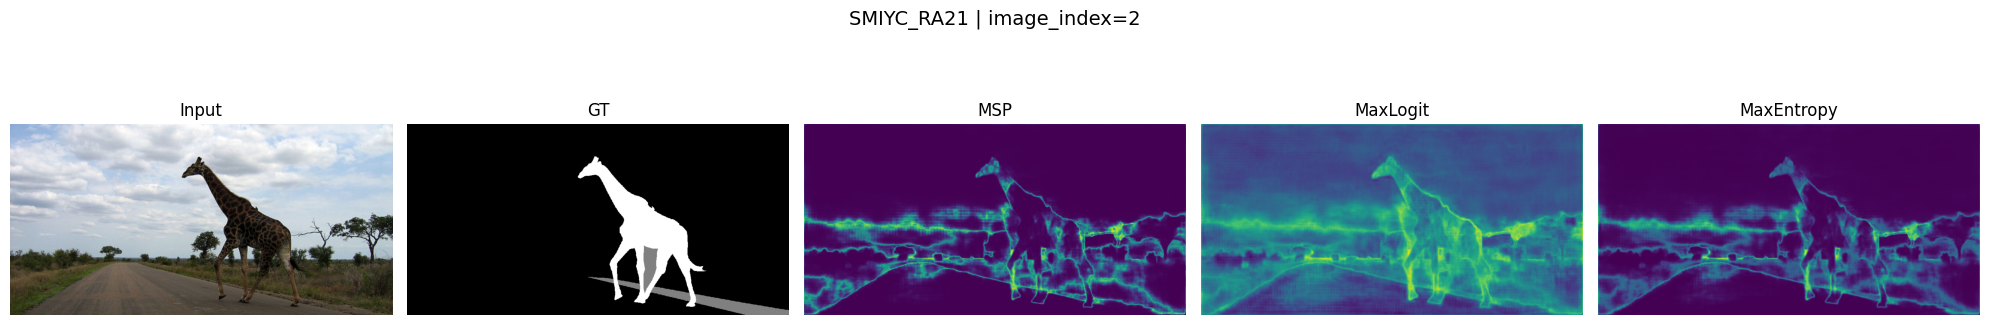

Generating figure for: SMIYC_RO21
Saved figure to: /content/outputs_step7/visualizations/SMIYC_RO21_idx2.png


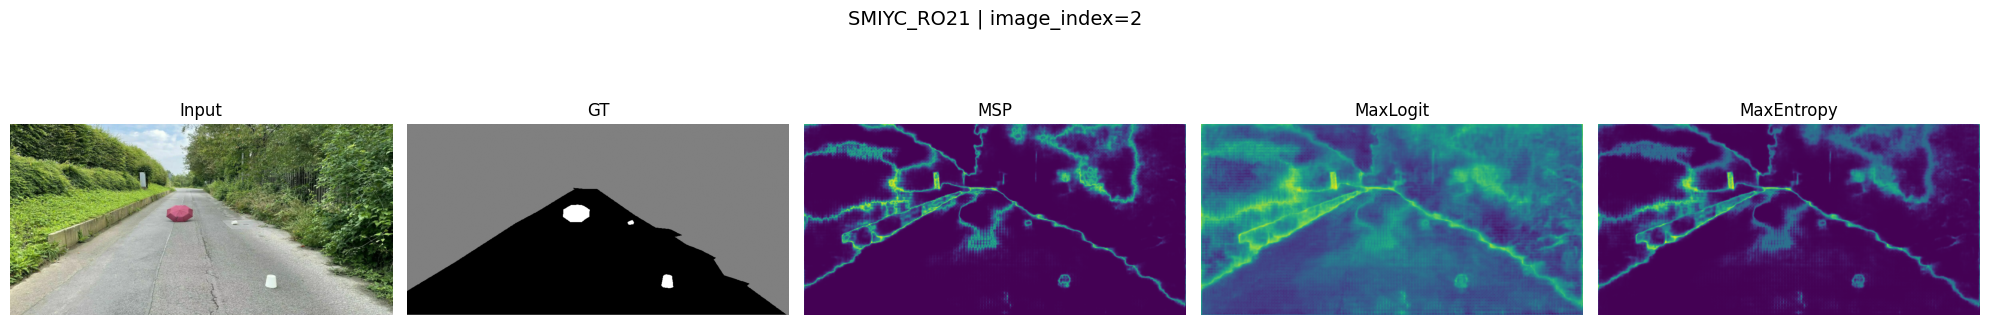

Generating figure for: FS_LF
Saved figure to: /content/outputs_step7/visualizations/FS_LF_idx2.png


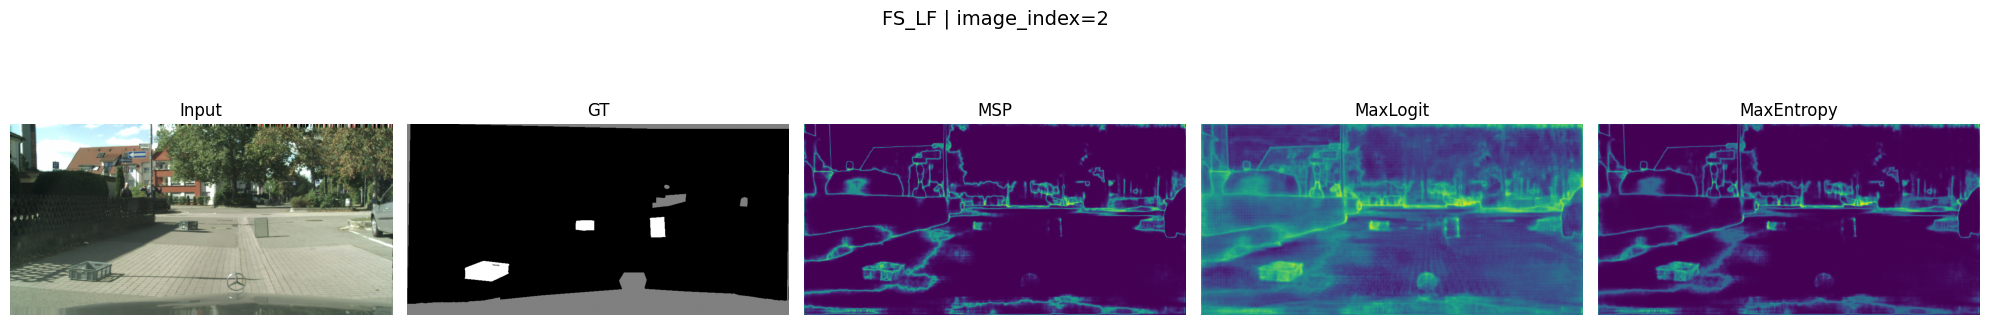

Generating figure for: FS_Static
Saved figure to: /content/outputs_step7/visualizations/FS_Static_idx2.png


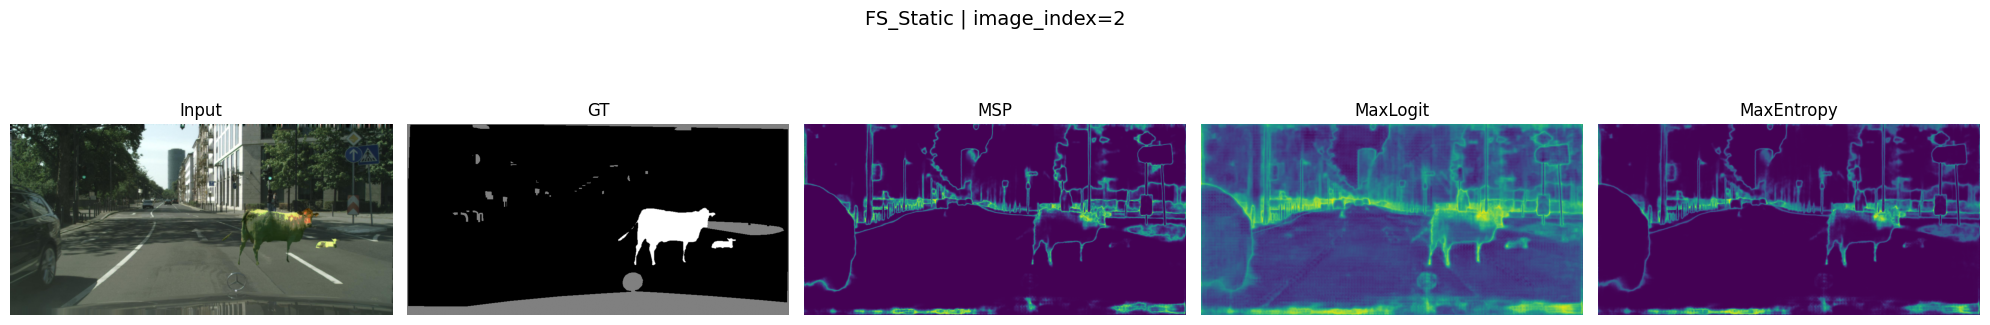

Generating figure for: RoadAnomaly
Saved figure to: /content/outputs_step7/visualizations/RoadAnomaly_idx2.png


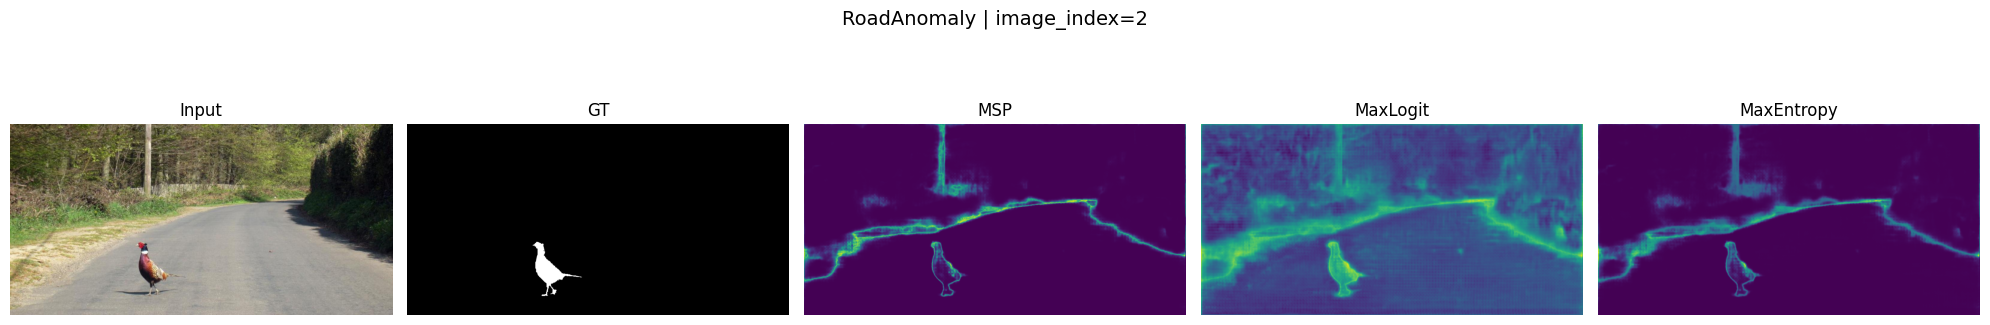


All saved figures:
/content/outputs_step7/visualizations/SMIYC_RA21_idx2.png
/content/outputs_step7/visualizations/SMIYC_RO21_idx2.png
/content/outputs_step7/visualizations/FS_LF_idx2.png
/content/outputs_step7/visualizations/FS_Static_idx2.png
/content/outputs_step7/visualizations/RoadAnomaly_idx2.png


In [13]:
# Create one figure per dataset with Input / GT / MSP / MaxLogit / MaxEntropy

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

VIS_OUT_DIR = "/content/outputs_step7/visualizations"
os.makedirs(VIS_OUT_DIR, exist_ok=True)

def _prepare_gt_for_display(gt_array):
    """
    Convert GT mask to a clean visualization:
    0   -> black   (in-distribution)
    1   -> white   (anomaly)
    255 -> gray    (ignore)
    """
    vis = np.zeros_like(gt_array, dtype=np.float32)
    vis[gt_array == 0] = 0.0
    vis[gt_array == 1] = 1.0
    vis[gt_array == 255] = 0.5
    return vis

def generate_step7_figure(dataset_key, image_index=1, cmap="magma", save=True, show=True):
    """
    Create a single figure for one dataset and one image index.
    The figure contains:
    Input | GT | MSP | MaxLogit | MaxEntropy
    """

    # Check that the dataset key exists in the dataset dictionary
    if dataset_key not in ANOMALY_DATASETS:
        raise ValueError(f"Unknown dataset_key: {dataset_key}. Available keys: {list(ANOMALY_DATASETS.keys())}")

    dataset_root = ANOMALY_DATASETS[dataset_key]
    image_paths = get_image_paths(dataset_root)

    if len(image_paths) == 0:
        raise ValueError(f"No images found for dataset {dataset_key} at path: {dataset_root}")

    # Raise an error if the requested image index is invalid
    if image_index >= len(image_paths):
        raise ValueError(f"image_index={image_index} is out of range. Dataset has {len(image_paths)} images.")

    img_path = image_paths[image_index]
    gt_path = get_mask_path(img_path)

    if not os.path.exists(gt_path):
        raise ValueError(f"GT mask not found.\nImage path: {img_path}\nExpected GT path: {gt_path}")

    # Load input image
    img_pil = Image.open(img_path).convert("RGB")
    img_vis = input_transform(img_pil).permute(1, 2, 0).numpy()

    # Load GT
    gt_pil = Image.open(gt_path)
    gt_pil = target_transform(gt_pil)
    gt = np.array(gt_pil)
    gt = normalize_ood_mask(gt, gt_path)
    gt_vis = _prepare_gt_for_display(gt)

    # Forward pass once
    result = forward_erfnet(img_path)

    # Compute anomaly maps
    msp_map = compute_anomaly_result(result, "msp")
    maxlogit_map = compute_anomaly_result(result, "maxlogit")
    maxentropy_map = compute_anomaly_result(result, "maxentropy")

    # Plot
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(img_vis)
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(gt_vis, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("GT")
    axes[1].axis("off")

    axes[2].imshow(msp_map, cmap=cmap)
    axes[2].set_title("MSP")
    axes[2].axis("off")

    axes[3].imshow(maxlogit_map, cmap=cmap)
    axes[3].set_title("MaxLogit")
    axes[3].axis("off")

    axes[4].imshow(maxentropy_map, cmap=cmap)
    axes[4].set_title("MaxEntropy")
    axes[4].axis("off")

    plt.suptitle(f"{dataset_key} | image_index={image_index}", fontsize=14)
    plt.tight_layout()

    # Save
    out_path = os.path.join(VIS_OUT_DIR, f"{dataset_key}_idx{image_index}.png")
    if save:
        fig.savefig(out_path, bbox_inches="tight", dpi=200)
        print("Saved figure to:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path

# Generate and save one figure for each dataset
saved_paths = []

for dataset_key in ANOMALY_DATASETS.keys():
    print("=" * 80)
    print("Generating figure for:", dataset_key)
    print("=" * 80)
    try:
        out_path = generate_step7_figure(
            dataset_key=dataset_key,
            image_index=2,      # change this if you want another sample
            cmap="viridis",     # you can also try "viridis" or "magma"
            save=True,
            show=True
        )
        saved_paths.append(out_path)
    except Exception as e:
        print(f"Skipping {dataset_key} because of error: {e}")

print("\nAll saved figures:")
for p in saved_paths:
    print(p)